In [24]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1.5

### a)

In [6]:
x = np.array([1, 2])
f = np.array([3, 5])

def routine(x, f):
    N = len(x) - 1
    coeffs = np.polyfit(x, f, N)
    return np.polyval(coeffs, 0)

routine(x, f)

np.float64(0.9999999999999999)

### b)

In [ ]:
def neville_scheme(n, m, f) -> np.ndarray:
    h = 2.0 ** -np.arange(m + n + 1)
    fh = f(h)
    return np.array([
        [routine(h[j:j+k+1], fh[j:j+k+1]) for k in range(n + 1)]
        for j in range(m + 1)
    ])


array([[1.71828183, 0.87660325, 1.00747997],
       [1.29744254, 0.97476079, 1.00077785],
       [1.13610167, 0.99427358, 1.00008889],
       [1.06518762, 0.99863506, 1.00001063],
       [1.03191134, 0.99966674, 1.0000013 ],
       [1.01578904, 0.99991766, 1.00000016],
       [1.00785335, 0.99997954, 1.00000002],
       [1.00391644, 0.9999949 , 1.        ],
       [1.00195567, 0.99999873, 1.        ],
       [1.0009772 , 0.99999968, 1.        ],
       [1.00048844, 0.99999992, 1.        ]])

### c)

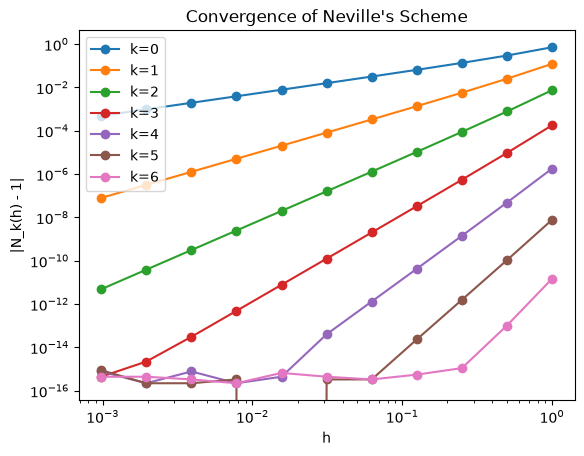

In [31]:
import matplotlib
n = 6
m = 10
f = lambda x: np.expm1(x) / x       

N = neville_scheme(n, m, f)
h = 2.0 ** -np.arange(m + 1)

columns = np.array([N[:, k] for k in range(n + 1)])

for k in range(n + 1):
    matplotlib.pyplot.loglog(h, np.abs(columns[k] - 1), 'o-', label=f'k={k}')
matplotlib.pyplot.legend()
matplotlib.pyplot.xlabel('h')
matplotlib.pyplot.ylabel('|N_k(h) - 1|')
matplotlib.pyplot.title('Convergence of Neville\'s Scheme')
matplotlib.pyplot.show()

### 1.5 c)
On the log-log plot all three graphs are straight lines, so $|N(:,k) - 1| \approx a\,h^{\alpha}$
($a$ is just a constant). The order of the error is given by the slope:

- $k = 0$: slope 1 → error $\sim h$
- $k = 1$: slope 2 → error $\sim h^2$
- $k = 2$: slope 3 → error $\sim h^3$

The higher the degree $k$, the smaller the error — even for large $h$ — and the faster it decreases as $h \to 0$.

**Extra (n = 6):** for higher $k$ the error stops decreasing at a floor. With $f(h) = (e^h - 1)/h$
the floor is ≈ $10^{-12}$ because of cancellation in $e^h - 1$ for small $h$.
Using `np.expm1(h)/h` (computes $e^h - 1$ without cancellation) the floor drops to ≈ $10^{-16}$:
we reach the machine precision of float64 ($\varepsilon \approx 2.2\cdot10^{-16}$), so no further accuracy is possible.